<a href="https://colab.research.google.com/github/MouseLand/cellpose/blob/main/notebooks/test_Cellpose-SAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cellpose-SAM: superhuman generalization for cellular segmentation

Marius Pachitariu, Michael Rariden, Carsen Stringer

[paper](https://www.biorxiv.org/content/10.1101/2025.04.28.651001v1) | [code](https://github.com/MouseLand/cellpose)

This notebook explains processing example 2D and 3D images using the Cellpose package on Google Colab using the GPU.

### Make sure you have GPU access enabled by going to Runtime -> Change Runtime Type -> Hardware accelerator and selecting GPU

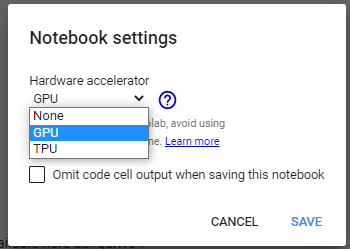

In [19]:
import sys
sys.path.append('/ifshome/abenneck/docs_public/libraries/cellpose')

import os
cwd = os.getcwd()

### Install Cellpose-SAM

In [3]:
# !uv pip install git+https://www.github.com/mouseland/cellpose.git
# !uv pip install git+https://github.com/facebookresearch/dinov3.git

Check GPU and instantiate model - will download weights.

In [5]:
import numpy as np
from cellpose import models, core, io, plot
from pathlib import Path
from tqdm import trange
import matplotlib.pyplot as plt

io.logger_setup() # run this to get printing of progress

#Check if colab notebook instance has GPU access
# if core.use_gpu()==False:
#   raise ImportError("No GPU access, change your runtime")

model = models.CellposeModel(gpu=False)

### You can also use other pretrained models, like the DINO models 
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino")
# model = models.CellposeModel(gpu=True, pretrained_model="cpdino-vitb")

[GUI INFO] : WRITING LOG OUTPUT TO /ifshome/abenneck/.cellpose/run.log

cellpose version: 	unknown 
platform:       	linux 
python version: 	3.9.19 
torch version:  	2.8.0+cu128
2026-08-17 08:26:50,105 [io INFO] WRITING LOG OUTPUT TO /ifshome/abenneck/.cellpose/run.log
2026-08-17 08:26:50,106 [io INFO] 
cellpose version: 	unknown 
platform:       	linux 
python version: 	3.9.19 
torch version:  	2.8.0+cu128
2026-08-17 08:26:50,106 [core INFO] >>>> using CPU
2026-08-17 08:26:50,107 [core INFO] >>>> using CPU
2026-08-17 08:26:50,108 [models INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam_v2" to /ifshome/abenneck/.cellpose/models/cpsam_v2



100%|██████████| 1.15G/1.15G [00:14<00:00, 83.2MB/s]  


2026-08-17 08:27:09,314 [models INFO] >>>> loading model /ifshome/abenneck/.cellpose/models/cpsam_v2


### Download example images

100%|██████████| 21.3M/21.3M [00:02<00:00, 9.60MB/s]
100%|██████████| 1.63M/1.63M [00:00<00:00, 3.03MB/s]


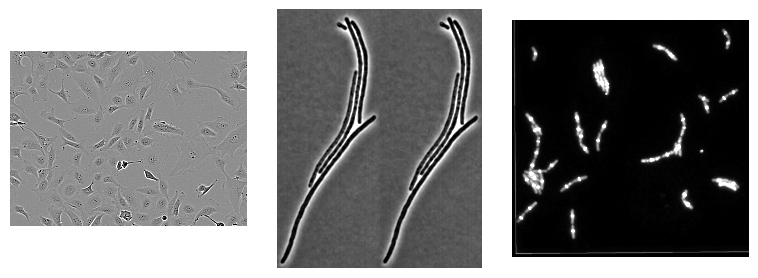

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from cellpose import utils, io

# download example 2D images from website
url = "http://www.cellpose.org/static/data/imgs_cyto3.npz"
filename = "imgs_cyto3.npz"
utils.download_url_to_file(url, filename)

# download 3D tiff
url = "http://www.cellpose.org/static/data/rgb_3D.tif"
utils.download_url_to_file(url, os.path.join(cwd,"rgb_3D.tif"))

dat = np.load(filename, allow_pickle=True)["arr_0"].item()

imgs = dat["imgs"]
masks_true = dat["masks_true"]

plt.figure(figsize=(8,3))
for i, iex in enumerate([9, 16, 21]):
    img = imgs[iex].squeeze()
    plt.subplot(1,3,1+i)
    plt.imshow(img[0], cmap="gray", vmin=0, vmax=1)
    plt.axis('off')
plt.tight_layout()
plt.show()

### Run Cellpose-SAM

In [7]:
masks_pred, flows, styles = model.eval(imgs, niter=1000) # using more iterations for bacteria


2026-08-17 08:37:10,316 [utils INFO] 100%|##########| 24/24 [08:10<00:00, 20.43s/it]


plot results

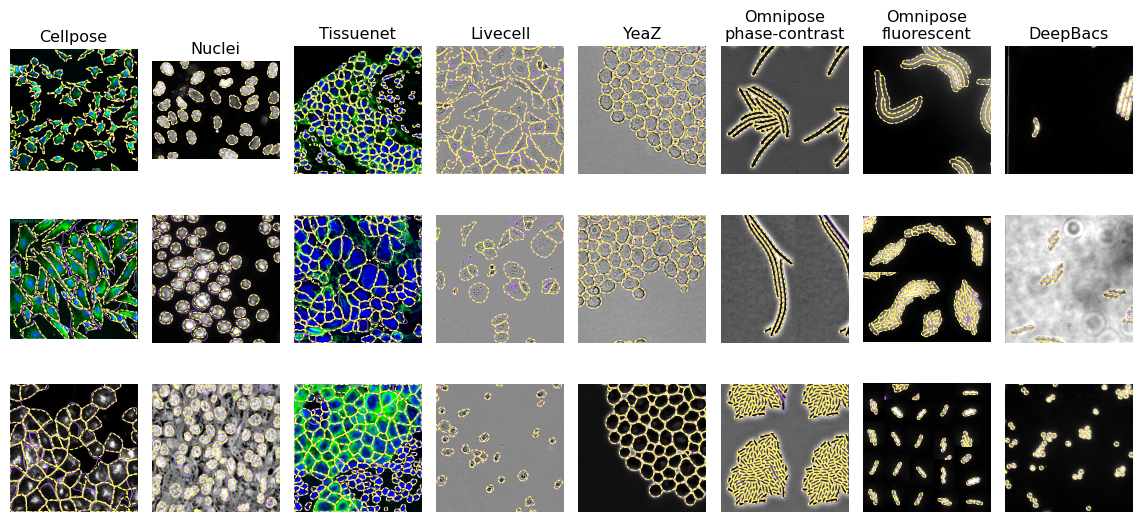

In [8]:
from cellpose import transforms, plot

titles = [
        "Cellpose", "Nuclei", "Tissuenet", "Livecell", "YeaZ",
         "Omnipose\nphase-contrast", "Omnipose\nfluorescent",
        "DeepBacs"
    ]

plt.figure(figsize=(12,6))
ly = 400
for iex in range(len(imgs)):
    img = imgs[iex].squeeze().copy()
    img = np.clip(transforms.normalize_img(img, axis=0), 0, 1) # normalize images across channel axis
    ax = plt.subplot(3, 8, (iex%3)*8 + (iex//3) +1)
    if img[1].sum()==0:
        img = img[0]
        ax.imshow(img, cmap="gray")
    else:
        # make RGB from 2 channel image
        img = np.concatenate((np.zeros_like(img)[:1], img), axis=0).transpose(1,2,0)
        ax.imshow(img)
    ax.set_ylim([0, min(400, img.shape[0])])
    ax.set_xlim([0, min(400, img.shape[1])])


    # GROUND-TRUTH = PURPLE
    # PREDICTED = YELLOW
    outlines_gt = utils.outlines_list(masks_true[iex])
    outlines_pred = utils.outlines_list(masks_pred[iex])
    for o in outlines_gt:
        plt.plot(o[:,0], o[:,1], color=[0.7,0.4,1], lw=0.5)
    for o in outlines_pred:
        plt.plot(o[:,0], o[:,1], color=[1,1,0.3], lw=0.75, ls="--")
    plt.axis('off')

    if iex%3 == 0:
        ax.set_title(titles[iex//3])

plt.tight_layout()
plt.show()

# Run Cellpose-SAM in 3D

There are two ways to run cellpose in 3D, this cell shows both, choose which one works best for you.

First way: computes flows from 2D slices and combines into 3D flows to create masks



In [18]:
img_3D.shape

(75, 2, 75, 75)

In [9]:
img_3D = io.imread("rgb_3D.tif")


# 1. computes flows from 2D slices and combines into 3D flows to create masks
masks, flows, _ = model.eval(img_3D, z_axis=0, channel_axis=1,
                                batch_size=32,
                                do_3D=True, flow3D_smooth=1)


2026-08-17 08:39:12,386 [io INFO] reading tiff with 150 planes


100%|██████████| 150/150 [00:00<00:00, 5440.32it/s]

2026-08-17 08:39:12,431 [core INFO] running YX: 75 planes of size (75, 75)
2026-08-17 08:39:12,432 [utils INFO] 0%|          | 0/3 [00:00<?, ?it/s]


2026-08-17 08:40:55,564 [utils INFO] 100%|##########| 3/3 [01:43<00:00, 34.38s/it]
2026-08-17 08:40:55,568 [core INFO] running ZY: 75 planes of size (75, 75)
2026-08-17 08:43:21,068 [utils INFO] 100%|##########| 3/3 [02:25<00:00, 48.50s/it]
2026-08-17 08:43:21,072 [core INFO] running ZX: 75 planes of size (75, 75)
2026-08-17 08:45:34,083 [utils INFO] 100%|##########| 3/3 [02:13<00:00, 44.34s/it]
2026-08-17 08:45:34,090 [models INFO] network run in 381.66s
2026-08-17 08:45:34,091 [models INFO] smoothing flows with ZYX sigma=[1, 1, 1]
2026-08-17 08:45:36,590 [models INFO] masks created in 2.00s


In [21]:
def cellpose_to_bb_list(mask, verbose=False):
    """
    Converts an integer-valued array into a set of bounding boxes around each unique instance.
    """
    # 0: Bg, 1: Annotated bg, 2+: Cell ID
    bb_out = []
    vals_to_skip = [0]
    n_cells = len(np.unique(mask)) - 1 # 0 is bg
    for val in np.unique(mask):
        if val in vals_to_skip:
            continue
        mask_cell = np.copy(mask)
        mask_cell[mask_cell != val] = 0.0
        mask_cell[mask_cell == val] = 1.0
        if verbose:
            print(f'Cell {(val-1).astype(int)} / {n_cells} volume of {np.sum(mask_cell).astype(int)} voxels')
        all_x, all_y, all_z = np.where(mask_cell == 1.0)
        print(f'{val}: ')
        print(all_x, all_y, all_z,'\n')
        bb_out.append([min(all_x).item(), max(all_x).item(), min(all_y).item(), max(all_y).item(), min(all_z).item(), max(all_z).item(), int(val)])
    return bb_out

cellpose_to_bb_list(masks)

1: 
[ 0  0  0 ... 13 13 13] [0 0 0 ... 7 7 7] [51 52 53 ... 57 58 59] 

2: 
[ 8  8  8 ... 55 55 55] [33 33 33 ... 30 30 30] [30 31 32 ... 31 32 33] 

3: 
[10 10 10 10 10 10 10 11 11 11 11 11 11 11 11 11 11 11 11 11 12 12 12 12
 12 12 12 12 12 12 12 12 13 13 13 13 13 13 13 13 13 13 14 14 14 14 14 15
 15 15] [70 71 71 71 71 72 72 70 70 70 70 71 71 71 71 71 72 72 72 72 70 70 70 71
 71 71 71 71 72 72 72 72 70 71 71 71 71 72 72 72 72 73 71 71 72 72 72 71
 72 72] [46 45 46 47 48 46 47 45 46 47 48 45 46 47 48 49 45 46 47 48 45 46 47 45
 46 47 48 49 45 46 47 48 45 45 46 47 48 45 46 47 48 45 45 46 45 46 47 45
 45 46] 

4: 
[25 25 26 ... 72 72 72] [73 73 72 ... 73 73 73] [19 20 19 ... 17 18 19] 

5: 
[29 29 29 ... 74 74 74] [1 2 2 ... 9 9 9] [40 37 38 ... 37 38 39] 

6: 
[30 31 31 ... 60 60 60] [6 1 1 ... 5 6 6] [1 2 3 ... 1 1 2] 

7: 
[33 33 33 ... 74 74 74] [26 26 26 ... 41 41 41] [11 12 13 ...  1  2  3] 

8: 
[34 34 34 ... 74 74 74] [42 42 42 ... 45 45 46] [60 61 62 ... 58 59 56] 

9: 
[71 71

[[0, 13, 0, 21, 48, 74, 1],
 [8, 55, 0, 44, 21, 49, 2],
 [10, 15, 70, 73, 45, 49, 3],
 [25, 72, 54, 74, 1, 33, 4],
 [29, 74, 0, 18, 20, 52, 5],
 [30, 60, 0, 19, 0, 7, 6],
 [33, 74, 1, 44, 0, 22, 7],
 [34, 74, 6, 61, 37, 74, 8],
 [71, 74, 64, 73, 63, 73, 9]]

Second way: computes masks in 2D slices and stitches masks in 3D based on mask overlap

Note stitching (with stitch_threshold > 0) can also be used to track cells over time.

In [10]:
# 2. computes masks in 2D slices and stitches masks in 3D based on mask overlap
print('running cellpose 2D + stitching masks')
masks_stitched, flows_stitched, _ = model.eval(img_3D, z_axis=0, channel_axis=1,
                                                  batch_size=32,
                                                  do_3D=False, stitch_threshold=0.5)

running cellpose 2D + stitching masks
2026-08-17 08:47:19,704 [utils INFO] 100%|##########| 3/3 [01:43<00:00, 34.36s/it]
2026-08-17 08:47:19,705 [models INFO] network run in 103.08s
2026-08-17 08:47:22,096 [utils INFO] 100%|##########| 75/75 [00:02<00:00, 31.39it/s]
2026-08-17 08:47:22,097 [models INFO] stitching 75 planes using stitch_threshold=0.500 to make 3D masks


100%|██████████| 74/74 [00:00<00:00, 548.90it/s]

2026-08-17 08:47:22,241 [models INFO] masks created in 2.54s


Results from 3D flows => masks computation

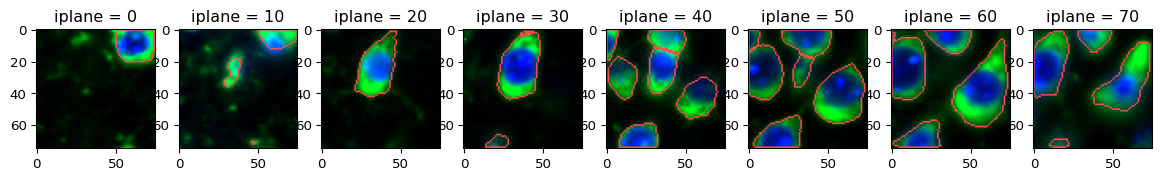

In [11]:
# DISPLAY RESULTS 3D flows => masks
plt.figure(figsize=(15,3))
for i,iplane in enumerate(np.arange(0,75,10,int)):
  img0 = plot.image_to_rgb(img_3D[iplane, [1,0]].copy(), channels=[2,3])
  plt.subplot(1,8,i+1)
  outlines = utils.masks_to_outlines(masks[iplane])
  outX, outY = np.nonzero(outlines)
  imgout= img0.copy()
  imgout[outX, outY] = np.array([255,75,75])
  plt.imshow(imgout)
  plt.title('iplane = %d'%iplane)

Results from stitching

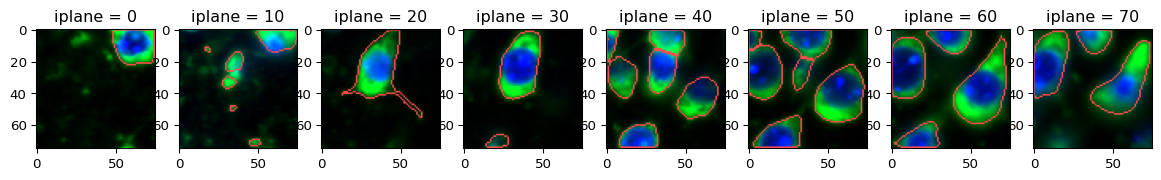

In [12]:
# DISPLAY RESULTS stitching
plt.figure(figsize=(15,3))
for i,iplane in enumerate(np.arange(0,75,10,int)):
  img0 = plot.image_to_rgb(img_3D[iplane, [1,0]].copy(), channels=[2,3])
  plt.subplot(1,8,i+1)
  outlines = utils.masks_to_outlines(masks_stitched[iplane])
  outX, outY = np.nonzero(outlines)
  imgout= img0.copy()
  imgout[outX, outY] = np.array([255,75,75])
  plt.imshow(imgout)
  plt.title('iplane = %d'%iplane)